<a href="https://colab.research.google.com/github/Adriansyah67/PengolahanCitra_TI-2A_Adriansyah_A/blob/main/Jobsheet_5_Pengolahan_Citra_TI_2A_Adriansyah_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jobsheet 05: Segmentasi Gambar

## Praktikum

### Praktikum 1: Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)  

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


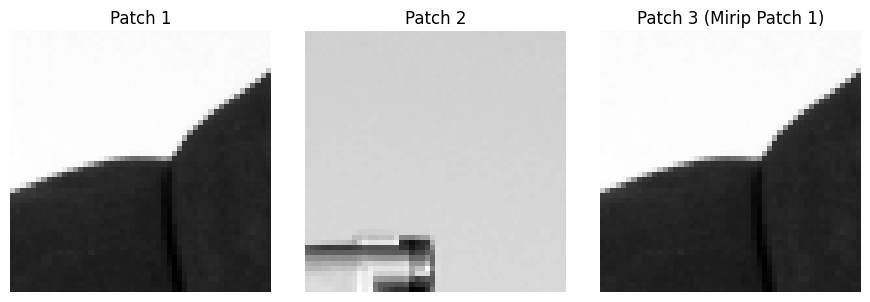

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Patch dari lokasi berbeda
patch3 = patch1 + 0.1  # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1)  # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

# Visualisasi patch
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### Praktikum 2: Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Same): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): 1.0000


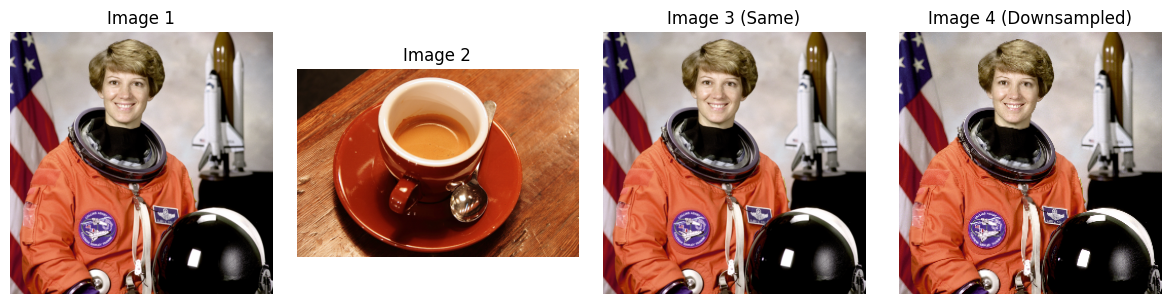

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi: Hitung histogram gabungan RGB
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

# 1. Muat citra
try:
    image1 = data.astronaut()
    image2 = data.coffee()
    image3 = data.astronaut()
    image4 = image1[::2, ::2, :]  # Downsampled
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Hitung histogram
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Same): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): {sim_14:.4f}")

# 5. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1); axes[0].set_title('Image 1'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('Image 2'); axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('Image 3 (Same)'); axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('Image 4 (Downsampled)'); axes[3].axis('off')
plt.tight_layout()
plt.show()


### Praktikum 3: Menghitung Structural Similarity Index (SSIM)

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2955
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


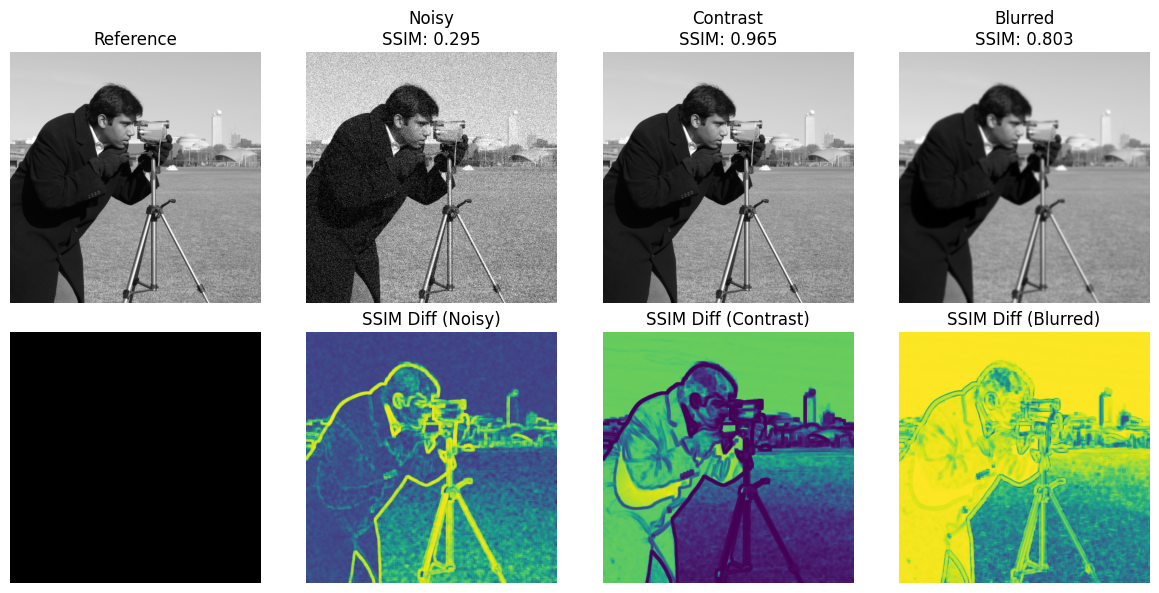

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat versi terdistorsi
image_same = image_ref.copy()
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)

# 3. Hitung SSIM
data_range = image_ref.max() - image_ref.min()
ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Cetak nilai SSIM
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# 5. Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray'); ax[0].set_title('Reference'); ax[0].axis('off')
ax[1].imshow(image_noisy, cmap='gray'); ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}'); ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray'); ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}'); ax[2].axis('off')
ax[3].imshow(image_blurred, cmap='gray'); ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}'); ax[3].axis('off')

ax[4].imshow(np.zeros_like(image_ref), cmap='gray'); ax[4].set_title(''); ax[4].axis('off')  # Kosong
ax[5].imshow(diff_noisy, cmap='viridis'); ax[5].set_title('SSIM Diff (Noisy)'); ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis'); ax[6].set_title('SSIM Diff (Contrast)'); ax[6].axis('off')
ax[7].imshow(diff_blurred, cmap='viridis'); ax[7].set_title('SSIM Diff (Blurred)'); ax[7].axis('off')

plt.tight_layout()
plt.show()


### Praktikum 4: Penerapan Template Matching

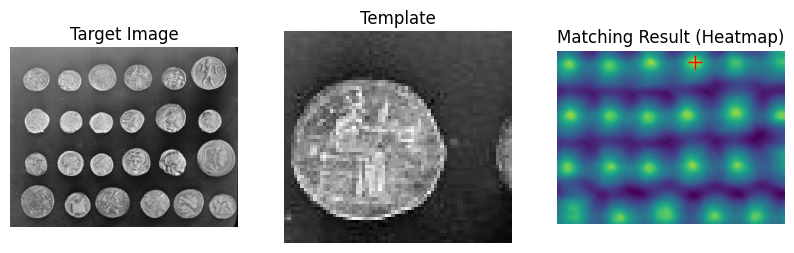

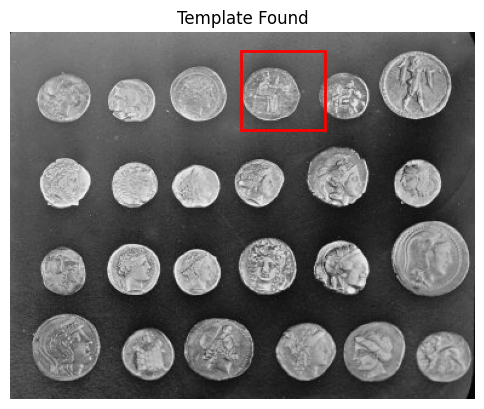

Template ditemukan di koordinat (x,y): (190, 15)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan buat/muat citra template
image = data.coins()
# Ambil salah satu koin sebagai template (sesuaikan koordinat jika perlu)
template = image[15:80, 190:260]

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation (metode default)
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
# np.argmax menemukan indeks linear, unravel_index mengubahnya ke koordinat 2D
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # Koordinat (x, y) dari sudut kiri atas template yang cocok

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

# Menampilkan heatmap hasil matching (opsional)
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()

# Tandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10)  # y, x karena ij adalah (row, col)

# Menampilkan kotak di lokasi terbaik pada citra asli (di plot terpisah agar lebih jelas)
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()

h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")


### Praktikum 5: Simulasi Content-Based Image Retrieval (CBIR) Sederhana

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


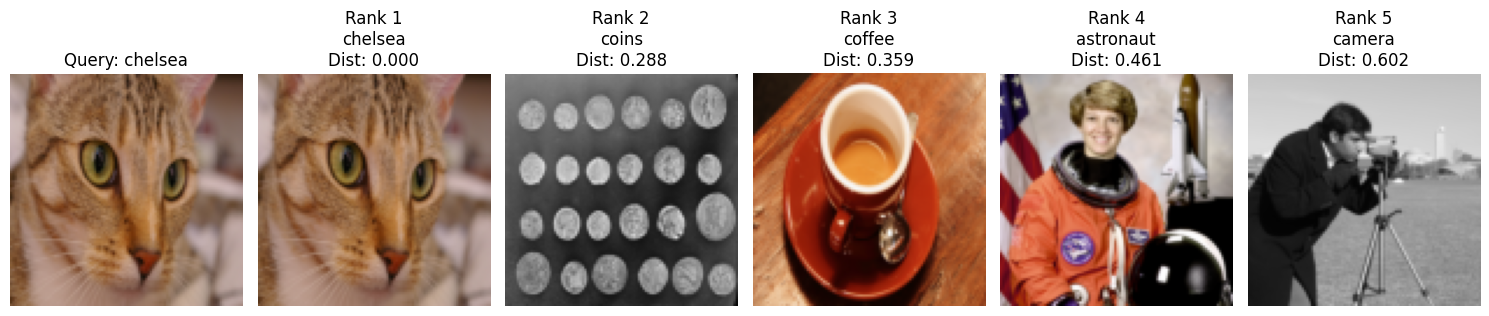

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi hitung histogram dari Praktikum 2
def calculate_rgb_histogram(image, bins=16):
    # Pastikan input float [0,1] dikonversi ke uint8 [0,255] untuk histogram
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1 (sum to 1)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)  # Avoid division by zero
    return hist_combined

# 1. Siapkan 'database' citra kecil dan citra query
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        # Pastikan semua citra berwarna (RGB) dan ukuran sama
        if img.ndim == 2:  # Jika grayscale, konversi ke RGB
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Pilih satu citra sebagai query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 3. Hitung jarak kemiripan (cosine distance)
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 4. Urutkan citra berdasarkan kemiripan
sorted_indices = np.argsort(distances)

# 5. Tampilkan hasil retrieval
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query image
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for rank, idx in enumerate(sorted_indices, start=1):
    ax = axes[rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()


## Tugas

### 3. Fitur Berbeda untuk CBIR

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

=== Retrieval berdasarkan Histogram RGB ===
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)

=== Retrieval berdasarkan Mean RGB ===
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


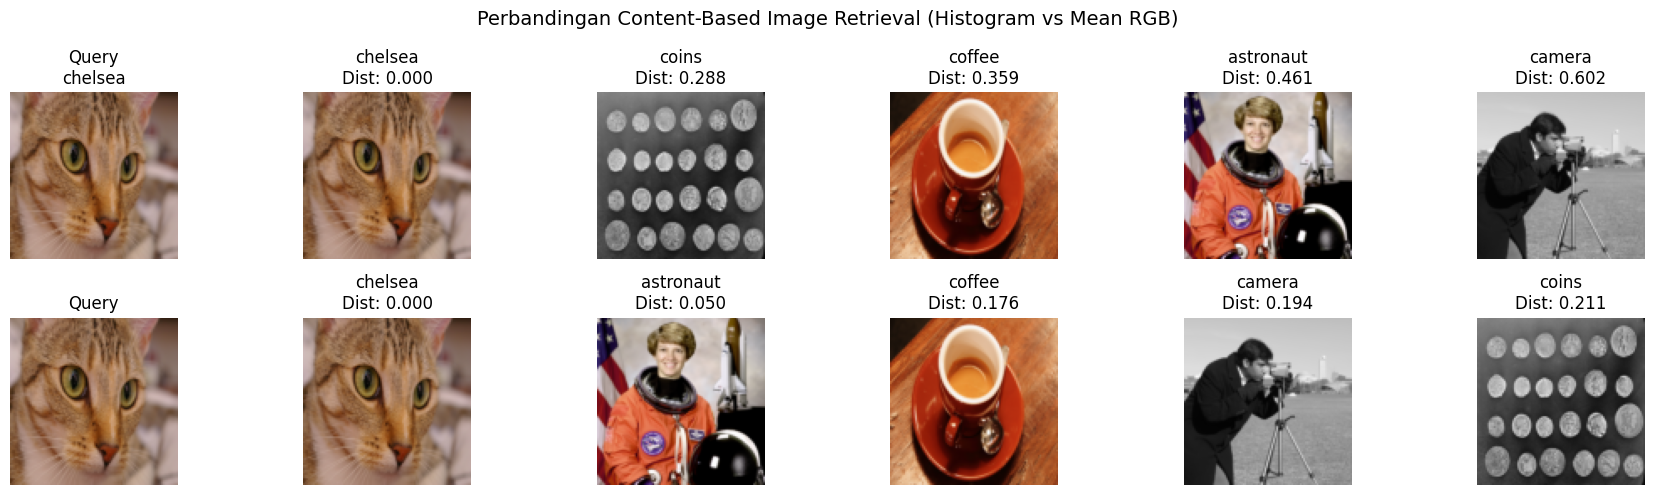

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# Fungsi fitur histogram RGB (48 dimensi)
def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    return hist_combined

# Fungsi fitur mean warna RGB (3 dimensi)
def calculate_mean_rgb(image):
    if image.ndim == 2:
        image = color.gray2rgb(image)
    mean_r = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_b = np.mean(image[:, :, 2])
    return np.array([mean_r, mean_g, mean_b])

# Database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []
database_means = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        database_means.append(calculate_mean_rgb(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih query image
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]
query_mean = database_means[query_index]

# Hitung jarak untuk kedua metode
dist_hist = [distance.cosine(query_hist, h) for h in database_hists]
dist_mean = [distance.euclidean(query_mean, m) for m in database_means]

# Urutkan indeks berdasarkan jarak
sorted_hist_idx = np.argsort(dist_hist)
sorted_mean_idx = np.argsort(dist_mean)

# Tampilkan hasil perbandingan
num_results = len(image_db_names)
fig, axes = plt.subplots(2, num_results + 1, figsize=(18, 5))

# Baris atas: histogram
axes[0, 0].imshow(query_image)
axes[0, 0].set_title(f"Query\n{query_image_name}")
axes[0, 0].axis('off')
print("\n=== Retrieval berdasarkan Histogram RGB ===")
for i, idx in enumerate(sorted_hist_idx):
    img = database_images[idx]
    dist = dist_hist[idx]
    axes[0, i+1].imshow(img)
    axes[0, i+1].set_title(f"{image_db_names[idx]}\nDist: {dist:.3f}")
    axes[0, i+1].axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {dist:.3f})")

# Baris bawah: mean warna
axes[1, 0].imshow(query_image)
axes[1, 0].set_title("Query")
axes[1, 0].axis('off')
print("\n=== Retrieval berdasarkan Mean RGB ===")
for i, idx in enumerate(sorted_mean_idx):
    img = database_images[idx]
    dist = dist_mean[idx]
    axes[1, i+1].imshow(img)
    axes[1, i+1].set_title(f"{image_db_names[idx]}\nDist: {dist:.3f}")
    axes[1, i+1].axis('off')
    print(f"Rank {i+1}: {image_db_names[idx]} (Distance: {dist:.3f})")

plt.suptitle("Perbandingan Content-Based Image Retrieval (Histogram vs Mean RGB)", fontsize=14)
plt.tight_layout()
plt.show()


### 4. Template Matching Invariant

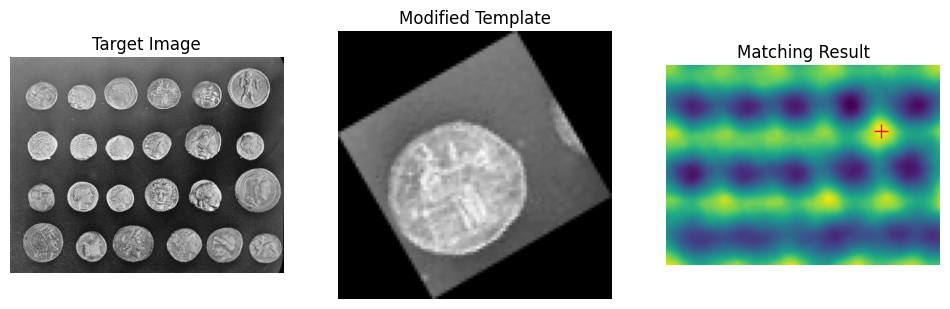

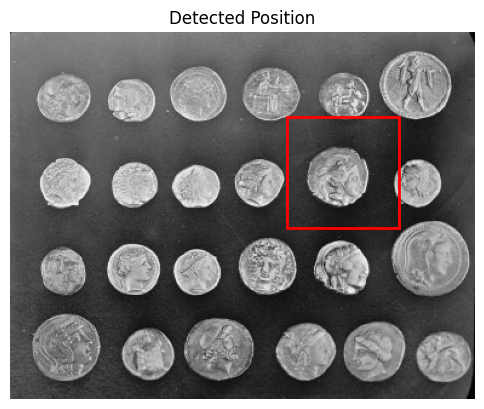

Template (yang dirotasi/resize) ditemukan di koordinat (x,y): (228, 70)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template

# 1. Muat citra target dan template asli
image = data.coins()
template_original = image[15:80, 190:260]

# 2. Lakukan rotasi dan resize pada template
# Resize (scale up/down)
template_resized = transform.resize(template_original, (50, 50), anti_aliasing=True)

# Rotasi (dalam derajat)
template_rotated = transform.rotate(template_original, angle=30, resize=True)

# Gunakan salah satu: rotasi atau resize
template = template_rotated  # <-- Coba juga dengan template_resized

# 3. Matching dengan template baru (yang telah diubah)
result = match_template(image, template)

# 4. Temukan lokasi skor tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # (x, y) sudut kiri atas

# 5. Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Modified Template')
ax[1].set_axis_off()

ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result')
ax[2].plot(x, y, 'r+', markersize=10)
ax[2].set_axis_off()

# Tambahkan kotak di lokasi hasil matching
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Detected Position')
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)
ax_main.set_axis_off()

plt.show()

print(f"Template (yang dirotasi/resize) ditemukan di koordinat (x,y): ({x}, {y})")
